# EN3160 Image Processing & Computer Vision - Assignment 01
**Name:** Meedeniya M.M.H

**Index Number:** 230407K

**GitHub Repository:** https://github.com/manjarimeedeniya/EN3160-Assignment-01

In [6]:
# Importing required libraries
import cv2 as cv
import numpy as np 
import matplotlib.pyplot as plt

## Question 1

A function is created to apply a piecewise intensity transformation to enhance the visual appearance of the image by mapping input intensity values according to the specified breakpoints.

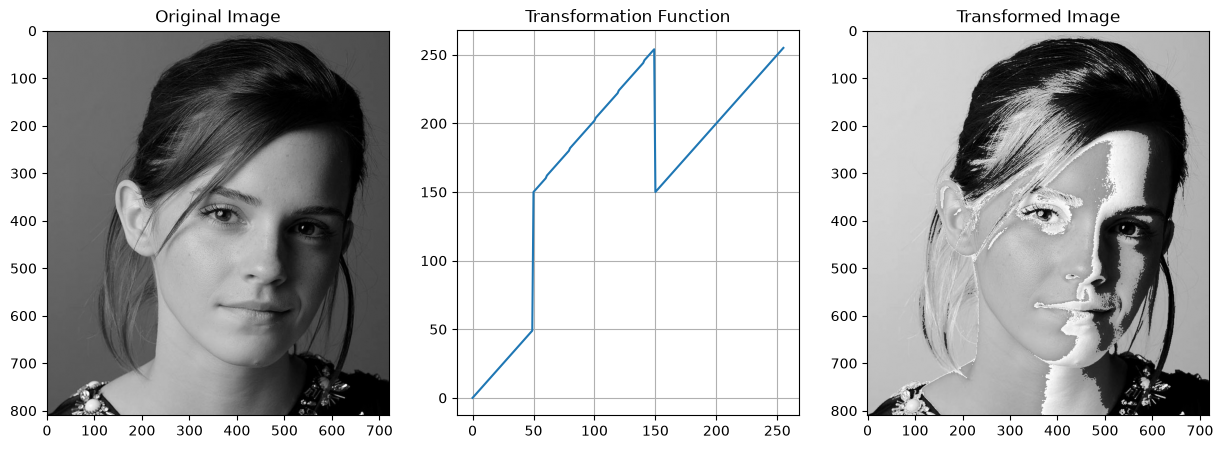

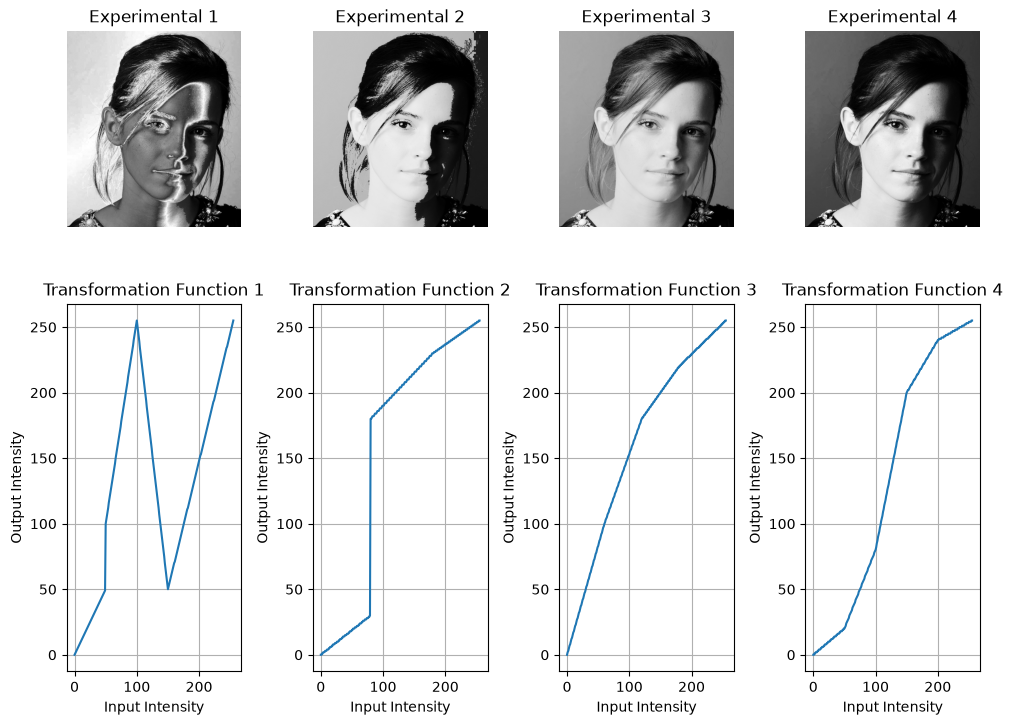

In [63]:
def intensity_transform(im,breakpoints):
    # Create an empty lookup table for intensities 0-255
    transform = np.zeros(256, dtype=np.uint8)

    # Generate each piecewise-linear segment
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        if x2 == x1:
            continue

        # Input intensity values in this segment
        x = np.arange(x1, x2 + 1)

        # Linear interpolation
        y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)

        transform[x] = np.round(y).astype(np.uint8)

    # Apply transformation using LUT
    transformed_image = cv.LUT(im, transform)

    return transformed_image, transform    

image1 = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question1.jpeg',cv.IMREAD_GRAYSCALE)  # Read the first image in grayscale
bps = np.array([[0,0],[50,50],[50,150],[150,255],[150,150],[255,255]])  # Define breakpoints 
image_transformed,transform=intensity_transform(image1, bps)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(image1,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(image_transformed,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform)
axes[1].set_title('Transformation Function') 
axes[1].grid('on')   
plt.show()  # Show the plots

# Experiment
bps1 = np.array([[0,0],[50,50],[50,100],[100,255],[150,50],[255,255]])
bps2 = np.array([[0,0],[80,30],[80,180],[180,230],[255,255]])
bps3 = np.array([[0,0],[60,100],[120,180],[180,220],[255,255]])
bps4 = np.array([[0,0],[50,20],[100,80],[150,200],[200,240],[255,255]])

image_transformed1, transform1 = intensity_transform(image1, bps1)
image_transformed2, transform2 = intensity_transform(image1, bps2)
image_transformed3, transform3 = intensity_transform(image1, bps3)
image_transformed4, transform4 = intensity_transform(image1, bps4)
fig, axes = plt.subplots(2, 4, figsize=(10, 8))

axes[0,0].imshow(image_transformed1, cmap='gray')
axes[0,0].set_title('Experimental 1')
axes[0,0].axis('off')
axes[1,0].plot(transform1)
axes[1,0].set_title('Transformation Function 1')
axes[1,0].set_xlabel('Input Intensity')
axes[1,0].set_ylabel('Output Intensity')
axes[1,0].grid('on')

axes[0,1].imshow(image_transformed2, cmap='gray')
axes[0,1].set_title('Experimental 2')
axes[0,1].axis('off')
axes[1,1].plot(transform2)
axes[1,1].set_title('Transformation Function 2')
axes[1,1].set_xlabel('Input Intensity')
axes[1,1].set_ylabel('Output Intensity')
axes[1,1].grid('on')

axes[0,2].imshow(image_transformed3, cmap='gray')
axes[0,2].set_title('Experimental 3')
axes[0,2].axis('off')
axes[1,2].plot(transform3)
axes[1,2].set_title('Transformation Function 3')
axes[1,2].set_xlabel('Input Intensity')
axes[1,2].set_ylabel('Output Intensity')
axes[1,2].grid('on')

axes[0,3].imshow(image_transformed4, cmap='gray')
axes[0,3].set_title('Experimental 4')
axes[0,3].axis('off')
axes[1,3].plot(transform4)
axes[1,3].set_title('Transformation Function 4')
axes[1,3].set_xlabel('Input Intensity')
axes[1,3].set_ylabel('Output Intensity')
axes[1,3].grid('on')
plt.tight_layout()
plt.show()

## Question 2

Detected Peaks -> Gray Matter: 149, White Matter: 169


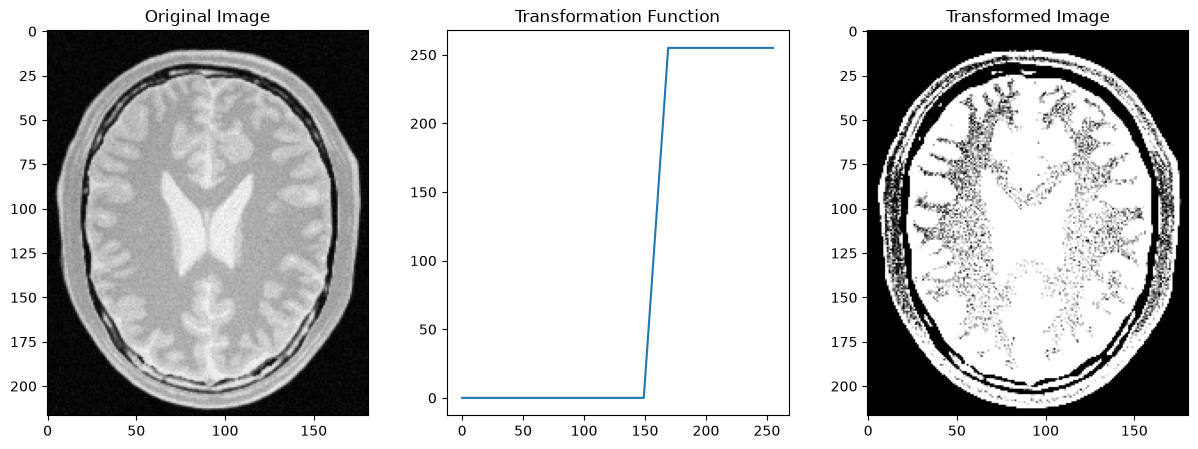

In [57]:
# 1. Load image
mri_image = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question2.jpeg', cv.IMREAD_GRAYSCALE)

# 2. Calculate histogram (ignoring pure black background < 10)
hist = cv.calcHist([mri_image], [0], None, [256], [0, 256]).flatten()
hist[:10] = 0  # Ignore background zeros

# 3. Smooth histogram using a simple moving average to clear noise
kernel = np.ones(15) / 15
smoothed_hist = np.convolve(hist, kernel, mode='same')

# 4. Find tissue ranges by splitting histogram into mid and high intensity regions
# Gray matter peak is in the middle (e.g., 50 to 150)
gm_peak = np.argmax(smoothed_hist[50:150]) + 50

# White matter peak is in the higher region (e.g., 150 to 240)
wm_peak = np.argmax(smoothed_hist[150:240]) + 150

print(f"Detected Peaks -> Gray Matter: {gm_peak}, White Matter: {wm_peak}")

# 5. Build dynamic breakpoints automatically
# (a) White Matter Accentuation: Ramps up around white matter peak
bps_wm_auto = np.array([
    [0, 0],
    [gm_peak, 0],
    [wm_peak, 255],
    [255, 255]
])

# (b) Gray Matter Accentuation: Peak shape around gray matter intensity
bps_gm_auto = np.array([
    [0, 0],
    [gm_peak - 30, 0],
    [gm_peak, 255],
    [wm_peak, 0],
    [255, 0]
])

# Apply transformations using your existing function
img_wm, transform_wm = intensity_transform(mri_image, bps_wm_auto)
img_gm, transform_gm = intensity_transform(mri_image, bps_gm_auto)

# Display the original and transformed images
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(mri_image,cmap='gray')
axes[0].set_title('Original Image')
axes[2].imshow(img_wm,cmap='gray')
axes[2].set_title('Transformed Image') 
axes[1].plot(transform_wm)
axes[1].set_title('Transformation Function')    
plt.show()  # Show the plots

## Question 3

In this step Gamma correction was applied to the L-plane using different γ values to observe how they affect the image brightness and intensity distribution.

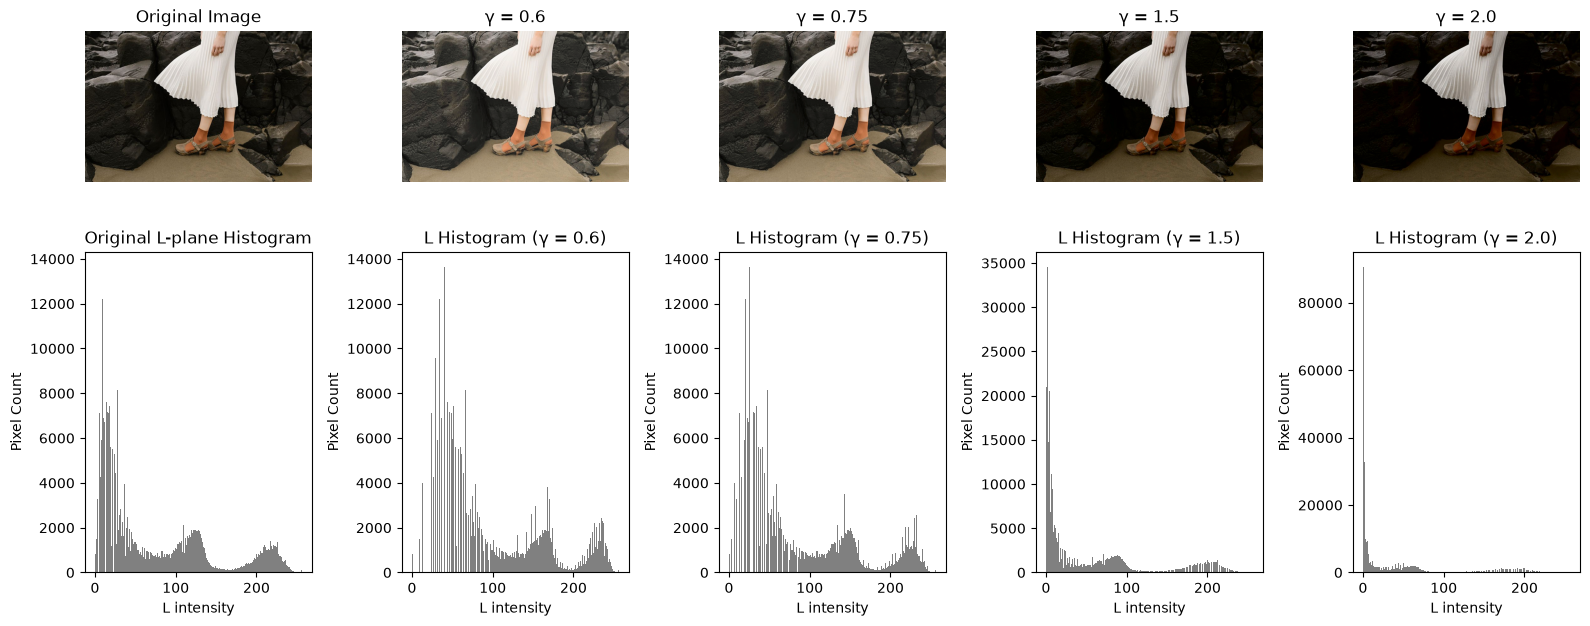

In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read Image
img_bgr = cv2.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question3.jpeg')  # Replace with your image file path
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Convert to LAB color space
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# 3. Define gamma values to experiment with
gamma_values = [0.6, 0.75, 1.5, 2.0]

fig, axes = plt.subplots(2,len(gamma_values) + 1,figsize=(16, 7))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

# Original histogram
axes[1, 0].hist(
    L.ravel(),
    bins=256,
    range=[0, 256],
    color='gray'
)
axes[1, 0].set_title("Original L-plane Histogram")
axes[1, 0].set_xlabel("L intensity")
axes[1, 0].set_ylabel("Pixel Count")
for i, gamma in enumerate(gamma_values):

    # Normalize L
    L_normalized = L / 255.0

    # Gamma correction
    L_corrected = np.uint8(
        np.clip(
            np.power(L_normalized, gamma) * 255,
            0,
            255
        )
    )

    # Merge corrected L with original a and b
    lab_corrected = cv2.merge([
        L_corrected,
        a,
        b
    ])

    # Convert back to RGB
    rgb_corrected = cv2.cvtColor(
        lab_corrected,
        cv2.COLOR_LAB2RGB
    )

    # Column number
    col = i + 1

    # Corrected image
    axes[0, col].imshow(rgb_corrected)
    axes[0, col].set_title(f"γ = {gamma}")
    axes[0, col].axis('off')

    # Corrected histogram
    axes[1, col].hist(
        L_corrected.ravel(),
        bins=256,
        range=[0, 256],
        color='gray'
    )
    axes[1, col].set_title(
        f"L Histogram (γ = {gamma})"
    )
    axes[1, col].set_xlabel("L intensity")
    axes[1, col].set_ylabel("Pixel Count")


plt.tight_layout()
plt.show()

Gamma correction showed that changing the γ value can effectively adjust the brightness and intensity distribution of the image, with lower γ values producing brighter results and higher γ values producing darker results.

As the final gamma value, γ = 0.5 was selected because it expands darker intensity values toward higher lightness values, making the darker regions of the image brighter and more visible

## Question 4


According to intensity transformation, 
$$f(x) = \min\left(x + a \times 128e^{-\frac{(x-128)^2}{2\sigma^2}},\,255\right)$$
The saturation enhancement was applied by modifying the S channel in the HSV color space with different values of \(a\), allowing the effect of saturation enhancement on the image to be compared.

### (a)

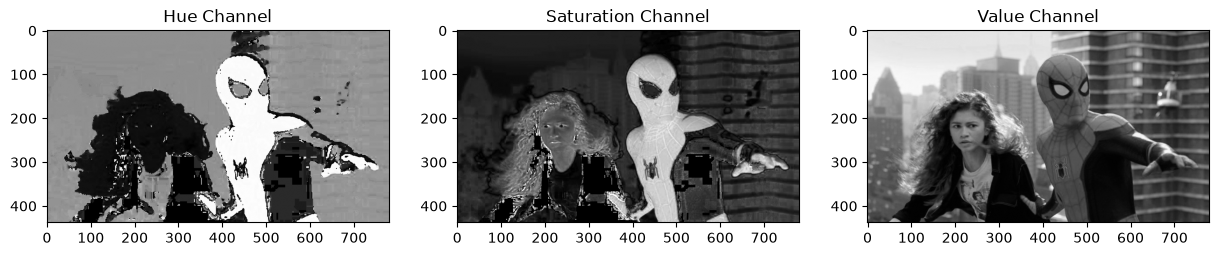

In [107]:
image4=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question4.jpeg')  # Read the image 
hsv=cv.cvtColor(image4,cv.COLOR_BGR2HSV)  # Convert to HSV color space
H,S,V=cv.split(hsv)  # Split into H, S, V channels

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(H,cmap='gray')
axes[0].set_title('Hue Channel')
axes[2].imshow(V,cmap='gray')
axes[2].set_title('Value Channel') 
axes[1].imshow(S,cmap='gray')
axes[1].set_title('Saturation Channel')    
plt.show()  # Show the plots

### (b)

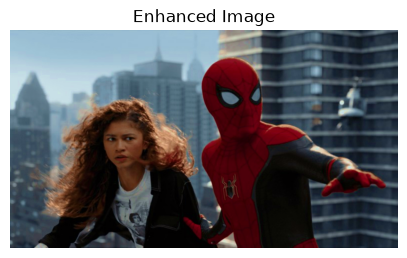

In [117]:
sigma=70
a=0.5
def transform_saturation(a):
    S_float = S.astype(np.float32)
    S_new = S_float + a * 128 * np.exp(-((S_float - 128) ** 2) / (2 * sigma ** 2))
    S_new = np.minimum(S_new, 255).astype(np.uint8)
    return S_new    

transform = transform_saturation(0.75)
# Merge modified saturation with original H and V
hsv_new = cv.merge([H, transform, V])
# Convert HSV to BGR to RGB
result = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)
enhanced_image1  = cv.cvtColor(result, cv.COLOR_BGR2RGB)

plt.figure(figsize=(5,4))
plt.imshow(enhanced_image1,cmap='gray')
plt.title('Enhanced Image')
plt.axis('off')
plt.show()

### (c)

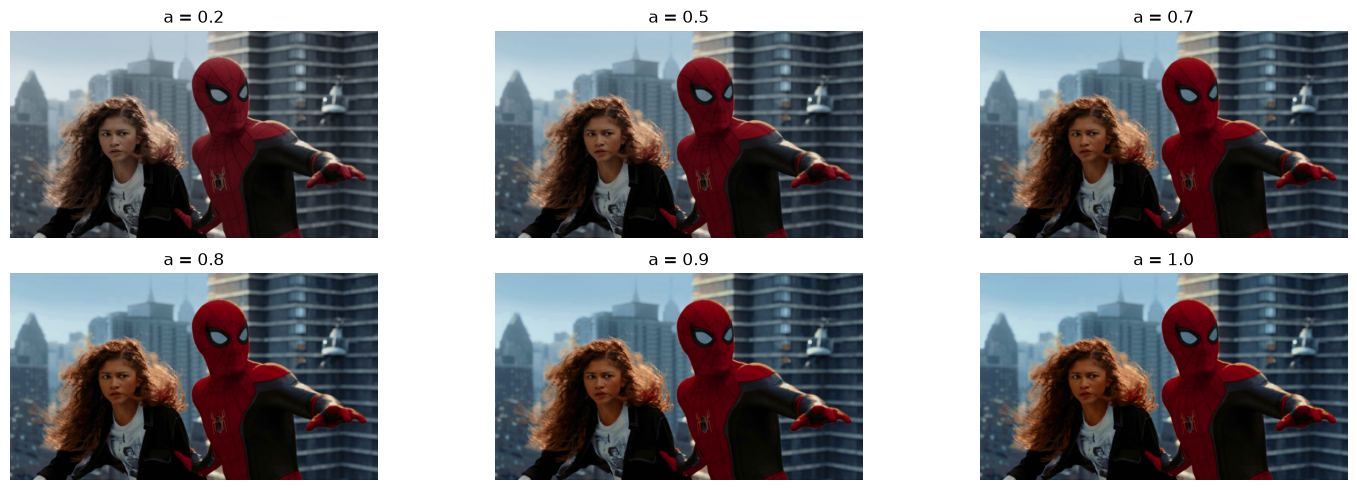

In [123]:
a_values = [0.2, 0.5, 0.7, 0.8, 0.9, 1.0]

plt.figure(figsize=(15, 5))

for i in range(len(a_values)):

    transform = transform_saturation(a_values[i])
    # Merge modified saturation with original H and V
    hsv_new = cv.merge([H, transform, V])
    # Convert HSV to BGR to RGB
    result = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)
    resulting_image  = cv.cvtColor(result, cv.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(resulting_image)
    plt.title(f'a = {a_values[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

The value of a was adjusted experimentally while visually comparing the resulting images. A value of a = 0.7 produced a visually pleasing result with enhanced saturation while maintaining natural-looking colors.

### (d)


In [124]:
#for the chosen value a=0.7, the image shows a significant enhancement in saturation, making the colors appear more vivid and vibrant. The Gaussian function applied to the saturation channel effectively boosts the mid-range saturation values while preventing oversaturation of already high saturation areas. This results in a more visually appealing image with improved color contrast and depth.
a = 0.7

transform= transform_saturation(a)
# Merge modified saturation with original H and V
hsv_new = cv.merge([H, transform, V])
# Convert HSV to BGR to RGB
result = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)
enhanced_image1  = cv.cvtColor(result, cv.COLOR_BGR2RGB)

C:\Users\USER\AppData\Local\Temp\ipykernel_9548\444926395.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


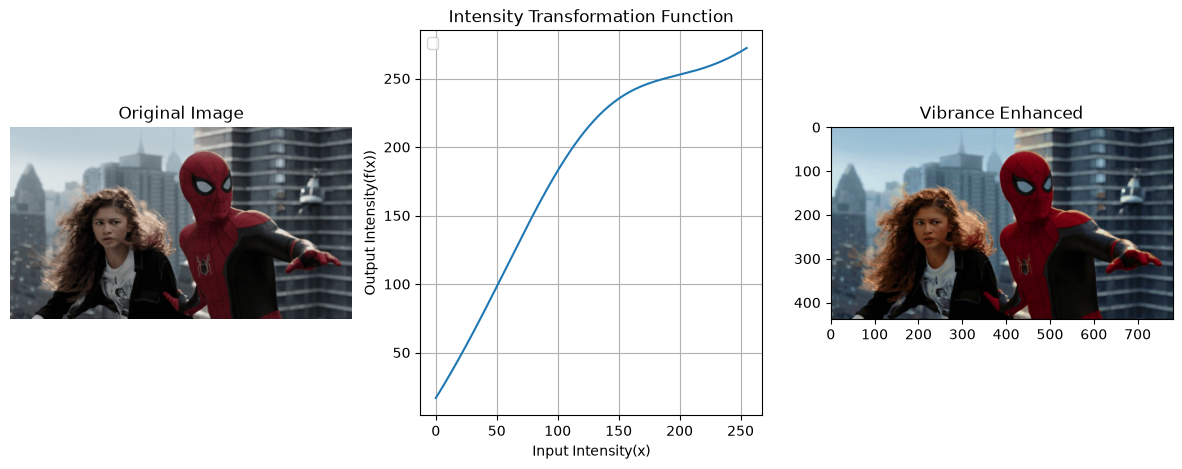

In [127]:
original_image=cv.cvtColor(image4,cv.COLOR_BGR2RGB)
x=np.arange(256,dtype=np.float32)
y = x + a*128*np.exp(-((x-128)**2)/(2*sigma**2))

fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[2].imshow(enhanced_image1)
axes[2].set_title('Vibrance Enhanced') 
axes[1].plot(x,y)
axes[1].set_title('Intensity Transformation Function')
axes[1].set_xlabel('Input Intensity(x)')
axes[1].set_ylabel('Output Intensity(f(x))')
axes[1].legend()
axes[1].grid()

## Queastion 5


In this step Histrogram Equalization is applied and Histogram equalization is used to improve image contrast by redistributing pixel intensities over a wider range.

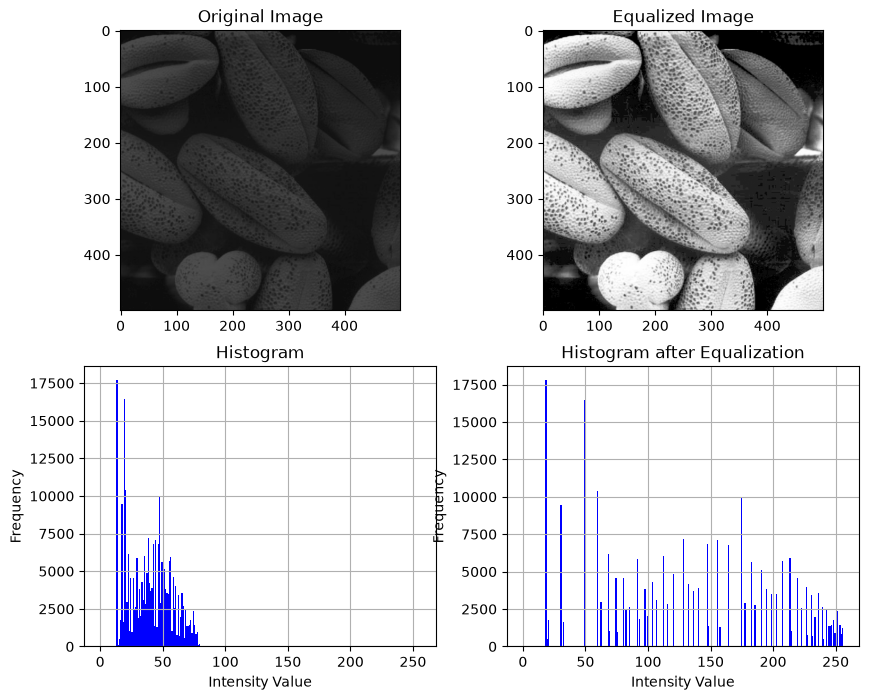

In [137]:
def histogram_equalization(image):
    histogram=np.zeros(256,dtype=np.int32) # Since there are intensity values from 0 to 255, we need an array of size 256
    for pixel in image.flatten():
        histogram[pixel] += 1  # Count the occurrences of each intensity value in the image

    # Now Calculate the cumulative distribution function (CDF) of the histogram
    cdf= np.cumsum(histogram)  

    num_pixels=image.size  # Total number of pixels in the image

    mapping = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        mapping[i] = round((cdf[i] / num_pixels) * 255) 

    equalized_image=mapping[image]  # Map the original pixel values to the new equalized values using the CDF
    return equalized_image

image5=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question5.tif',cv.IMREAD_GRAYSCALE)  # Read the image
equalized_image = histogram_equalization(image5)
original_image=cv.cvtColor(image5,cv.COLOR_GRAY2RGB)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# Images
axes[0, 0].imshow(original_image)
axes[0, 0].set_title('Original Image')

axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].set_title('Equalized Image')

# Histograms
axes[1, 0].hist(image5.ravel(), bins=256, range=[0, 256], color='blue')
axes[1, 0].set_title('Histogram')
axes[1, 0].set_xlabel('Intensity Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid('on')
axes[1, 1].hist(equalized_image.ravel(), bins=256, range=[0, 256], color='blue')
axes[1, 1].set_title('Histogram after Equalization')
axes[1, 1].set_xlabel('Intensity Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid('on')

## Question 6

(np.float64(-0.5), np.float64(1599.5), np.float64(899.5), np.float64(-0.5))

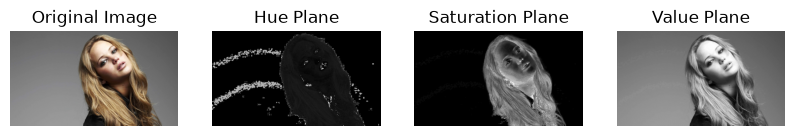

In [148]:
image6=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question6.jpeg')  # Read the image in gray scale
hsv=cv.cvtColor(image6,cv.COLOR_BGR2HSV)  # Convert to HSV color space
H,S,V=cv.split(hsv)
plt.figure(figsize=(10, 8))

plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(image6, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(H, cmap='gray')
plt.title('Hue Plane')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(S, cmap='gray')
plt.title('Saturation Plane')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(V, cmap='gray')
plt.title('Value Plane')
plt.axis('off')

Will choose the Saturation Channel to threshold in extract the foreground mask.


In [160]:
mask = cv.threshold(S,13,255,cv.THRESH_BINARY)[1]  # Create a binary mask 

In [ ]:
foreground = cv.bitwise_and(image6, image6, mask=mask)  # Apply the mask to the original image

foreground_hsv = cv.cvtColor(foreground, cv.COLOR_BGR2HSV)  # Convert the foreground to HSV color space
fg_H,fg_S,fg_V=cv.split(foreground_hsv)  # Split the foreground into H, S, V channels   

# Now we take the pixels belonging to foreground'
foreground_pixels = fg_V[fg_V > 0]  # Get the pixel values of the foreground (non-zero pixels)

histogram = np.zeros(256, dtype=np.int32)  # Since there are intensity values from 0 to 255, we need an array of size 256
for pixel in foreground_pixels:
    histogram[pixel] += 1  # Count the occurrences of each intensity value in the foreground    

In [162]:
cdf = np.cumsum(histogram)  # Calculate the cumulative distribution function (CDF) of the histogram 

In [163]:
total_foreground_pixels = np.sum(histogram)  # Total number of foreground pixels    
mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    mapping[i] = round((cdf[i] / total_foreground_pixels) * 255) 

equalized_V=mapping[fg_V]  # Map the original pixel values to the new equalized values using the CDF

(np.float64(-0.5), np.float64(1599.5), np.float64(899.5), np.float64(-0.5))

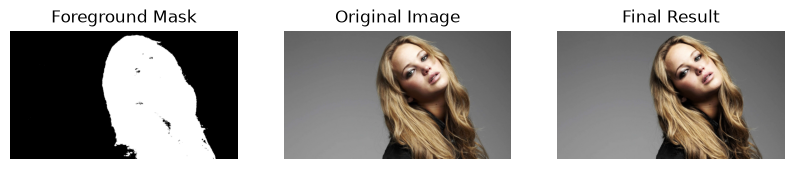

In [191]:
hsv_new = cv.merge([fg_H, fg_S, equalized_V])  # Combine the equalized foreground with the original background
equalized_foreground = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)  # Convert back to BGR color space

# Extract the foreground for visualization
background = cv.bitwise_and(image6,image6, mask=cv.bitwise_not(mask))  # Get the background by inverting the mask
result_image = background + equalized_foreground  # Combine the background and equalized foreground

fig,axes=plt.subplots(1,3,figsize=(10, 8))
axes[0]=plt.subplot(1, 3, 1)
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Foreground Mask')
axes[0].axis('off')

axes[1] = plt.subplot(1, 3, 2)
axes[1].imshow(cv.cvtColor(image6,cv.COLOR_BGR2RGB))
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2] = plt.subplot(1, 3, 3)
axes[2].imshow(cv.cvtColor(result_image,cv.COLOR_BGR2RGB))
axes[2].set_title('Final Result')
axes[2].axis('off')



The HSV-based segmentation and histogram equalization successfully extracted the foreground and enhanced its contrast. The final image showed improved visibility of the foreground while preserving the background.

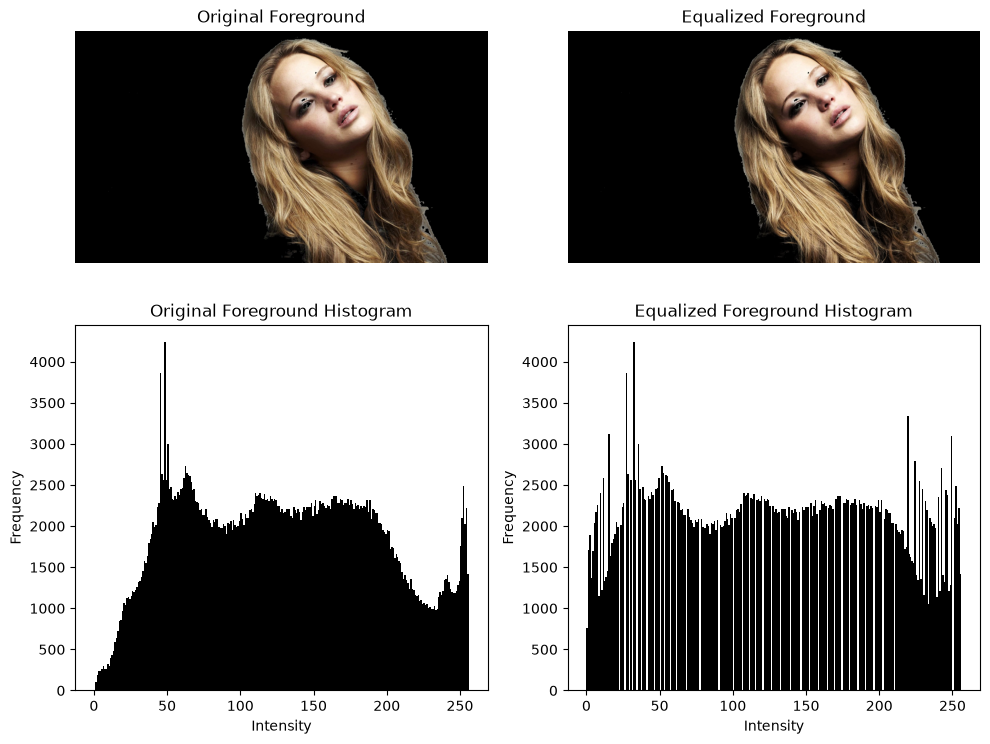

In [198]:
fig,axes=plt.subplots(2,2,figsize=(10, 8))
# Original foreground
axes[0,0].imshow(cv.cvtColor(foreground,cv.COLOR_BGR2RGB))
axes[0,0].set_title('Original Foreground')
axes[0,0].axis('off')

# Equalized foreground
axes[0,1].imshow(cv.cvtColor(equalized_foreground,cv.COLOR_BGR2RGB))
axes[0,1].set_title('Equalized Foreground')
axes[0,1].axis('off')

# Histogram of original foreground
axes[1,0].hist(foreground_pixels, bins=256, range=[0, 256], color='black')
axes[1,0].set_title('Original Foreground Histogram')
axes[1,0].set_xlabel('Intensity')
axes[1,0].set_ylabel('Frequency')

# Histogram of equalized foreground
# Get V values of equalized foreground
equalized_foreground_hsv = cv.cvtColor(
    equalized_foreground,
    cv.COLOR_BGR2HSV
)
equalized_V = equalized_foreground_hsv[:, :, 2]

# Only include foreground pixels
equalized_foreground_pixels = equalized_V[mask > 0]

axes[1,1].hist(
    equalized_foreground_pixels,
    bins=256,
    range=[0, 256],
    color='black'
)
axes[1,1].set_title('Equalized Foreground Histogram')
axes[1,1].set_xlabel('Intensity')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## Question 7


## (a)

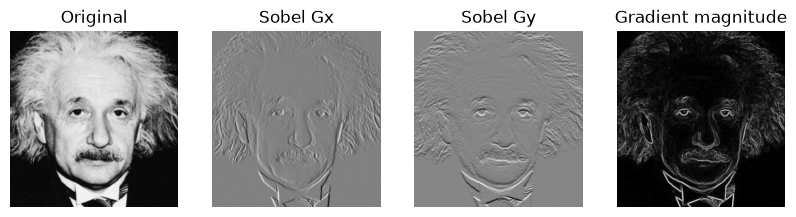

In [201]:
image7 = cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question7.jpeg', cv.IMREAD_GRAYSCALE)

# Sobel in x direction
Gx_Kernel = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])

# Sobel in y direction
Gy_Kernel = np.array([[-1, -2, -1],[0, 0, 0],[1, 2, 1]])

# Apply the kernels
Gx = cv.filter2D(image7, cv.CV_64F, Gx_Kernel)
Gy = cv.filter2D(image7, cv.CV_64F, Gy_Kernel)

# Gradient magnitude
G = np.sqrt(Gx**2 + Gy**2)

fig,axes=plt.subplots(1,4,figsize=(10, 8))

axes[0].imshow(image7, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(Gx, cmap='gray')
axes[1].set_title('Sobel Gx')
axes[1].axis('off')

axes[2].imshow(Gy, cmap='gray')
axes[2].set_title('Sobel Gy')
axes[2].axis('off')

axes[3].imshow(G, cmap='gray')
axes[3].set_title('Gradient magnitude')
axes[3].axis('off')
plt.show()

## (b)

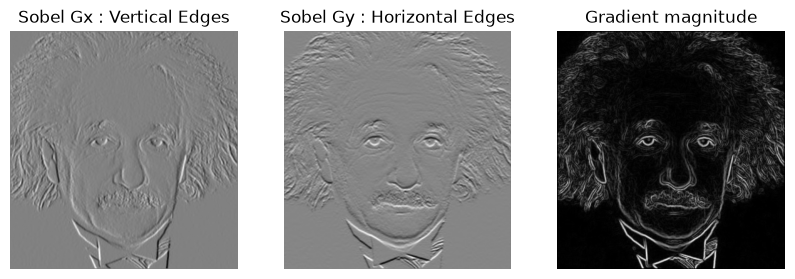

In [203]:
def sobel_filtering(image,kernel):
    rows, cols = image.shape
    filtered_image = np.zeros((rows, cols), dtype=np.float64) # This is what we are going to build yp

    for i in range(1, rows-1):
        for j in range(1, cols-1): # Here I ignored the border pixels to avoid boundary issues
            neighborhood_extracted = image[i-1:i+2, j-1:j+2]  # Extract the 3x3 neighborhood
            # Do the convolution operation: element-wise multiplication and sum
            calculated_value = np.sum(neighborhood_extracted * kernel)
            filtered_image[i, j] = calculated_value  # Assign the calculated value to the filtered

    return filtered_image

Gx=sobel_filtering(image7,Gx_Kernel)
Gy=sobel_filtering(image7,Gy_Kernel)
G = np.sqrt(Gx**2 + Gy**2)
fig,axes=plt.subplots(1,3,figsize=(10, 8))
axes[0].imshow(Gx, cmap='gray') 
axes[0].set_title('Sobel Gx : Vertical Edges')
axes[0].axis('off')
axes[1].imshow(Gy, cmap='gray')
axes[1].set_title('Sobel Gy : Horizontal Edges')
axes[1].axis('off')
axes[2].imshow(G, cmap='gray')
axes[2].set_title('Gradient magnitude')
axes[2].axis('off')
plt.show()


## (c) 
Using the seperabale property. This is mainly for efficiency


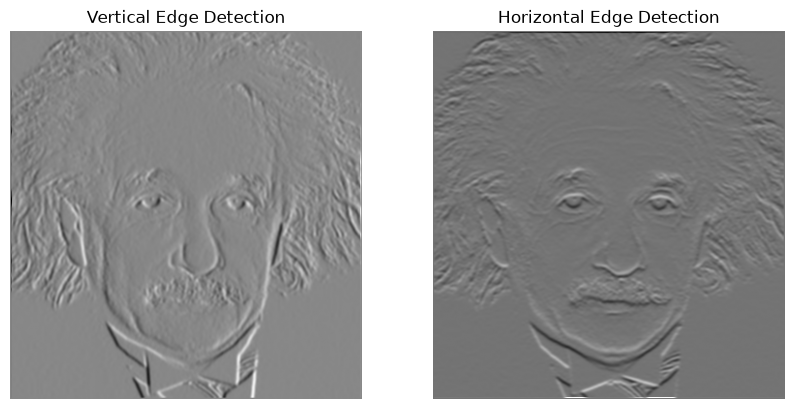

In [204]:
# First lets use Sobel filtering for vertical edge detection
horizontal_filter1 = np.array([1,0,-1]) 
vertical_smoothing1 =np.array([1,2,1]).reshape(3,1) # Here we reshape this as a column vector

image_after_vertical_filtering1= sobel_filtering(image7,vertical_smoothing1)

image_after_horizontal_filtering1 = sobel_filtering(image_after_vertical_filtering1,horizontal_filter1)
vertical_edges=image_after_horizontal_filtering1

# Then we perfom Horizontal edge detection
vertical_filter2 = np.array([1,0,-1]).reshape(3,1)   
horizontal_smoothing2 = np.array([1,2,1])

image_after_vertical_filtering2 = sobel_filtering(image7,horizontal_smoothing2)

image_after_horizontal_filtering2 = sobel_filtering(image_after_vertical_filtering1,vertical_filter2)
horizontal_edges=image_after_horizontal_filtering2

fig,axes=plt.subplots(1,2,figsize=(10, 8))
axes[0].imshow(vertical_edges, cmap='gray')
axes[0].set_title('Vertical Edge Detection')
axes[1].imshow(horizontal_edges, cmap='gray')
axes[1].set_title('Horizontal Edge Detection')
axes[0].axis('off')
axes[1].axis('off')
plt.show()



## Question 8


In [ ]:
def zoom_image(image, factor, method="nearest"):   
    if factor <= 0 or factor > 10:
        raise ValueError("Zoom factor must be in the range (0, 10].")
    
    height, width = image.shape[:2]    
    new_height = int(height * factor)
    new_width = int(width * factor)
    
    # Creating output image
    if len(image.shape) == 3:
        output = np.zeros((new_height, new_width, image.shape[2]), dtype=image.dtype)
    else:
        output = np.zeros((new_height, new_width), dtype=image.dtype)
    
    for y_new in range(new_height):
        for x_new in range(new_width):
            # Mapping new pixel position back to original image
            y_old = y_new / factor
            x_old = x_new / factor
            if method == "nearest":  
                # Find nearest pixel
                y = int(round(y_old))
                x = int(round(x_old))
                
                y = min(y, height - 1)
                x = min(x, width - 1)
                
                output[y_new, x_new] = image[y, x]
            
            elif method == "bilinear":   
                # Coordinates of surrounding pixels
                x1 = int(np.floor(x_old))
                x2 = min(x1 + 1, width - 1)
                
                y1 = int(np.floor(y_old))
                y2 = min(y1 + 1, height - 1)
                
                dx = x_old - x1
                dy = y_old - y1
                
                # Four neighboring pixels
                Q11 = image[y1, x1]
                Q21 = image[y1, x2]
                Q12 = image[y2, x1]
                Q22 = image[y2, x2]
                
                # Bilinear interpolation
                top = Q11 * (1 - dx) + Q21 * dx
                bottom = Q12 * (1 - dx) + Q22 * dx
                value = top * (1 - dy) + bottom * dy
                output[y_new, x_new] = np.clip(value, 0, 255)
            
            else:
                raise ValueError("Method must be 'nearest' or 'bilinear'")
    
    return output.astype(np.uint8)

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt


def process_images(original_image, small_image, zoom_factor):
    
    # Zoom the small image
    nearest_image = zoom_image(
        small_image,
        zoom_factor,
        method="nearest"
    )
    
    bilinear_image = zoom_image(
        small_image,
        zoom_factor,
        method="bilinear"
    )
    
    # Display all four
    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(cv.cvtColor(original_image, cv.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 4, 2)
    plt.imshow(cv.cvtColor(small_image, cv.COLOR_BGR2RGB))
    plt.title("Small Image")
    plt.axis("off")
    
    plt.subplot(1, 4, 3)
    plt.imshow(cv.cvtColor(nearest_image, cv.COLOR_BGR2RGB))
    plt.title("Nearest Neighbour")
    plt.axis("off")
    
    plt.subplot(1, 4, 4)
    plt.imshow(cv.cvtColor(bilinear_image, cv.COLOR_BGR2RGB))
    plt.title("Bilinear")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    return nearest_image, bilinear_image

nearest1, bilinear1 = process_images('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_original.png','C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_small.png',4)
nearest1, bilinear1 = process_images('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_original.png','C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_small.png',4)

nearest1, bilinear1 = process_images('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_original.png','C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_small.png',4)

nearest1, bilinear1 = process_images('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_original.png','C:\\Users\\USER\\EN3160-Assignment-01\\images\\question8a_small.png',4)


In [37]:
def normalized_ssd(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)

    ssd = np.sum((original - reconstructed) ** 2)

    normalized_ssd = ssd / np.sum(original ** 2)

    return normalized_ssd

In [38]:
nssd_nearest = normalized_ssd(original_image1, zoom_nearest1)
nssd_bilinear = normalized_ssd(original_image1, zoom_bilinear1)

print("Normalized SSD - Nearest Neighbor:", nssd_nearest)
print("Normalized SSD - Bilinear:", nssd_bilinear)

Normalized SSD - Nearest Neighbor: 0.009599429217788839
Normalized SSD - Bilinear: 0.007710873190589466


Bilinear interpolation gives a lower normalized SSD than nearest-neighbor interpolation. Therefore, the bilinear interpolation result is more similar to the original large image.

## Question 9


## (a)

<>:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
C:\Users\USER\AppData\Local\Temp\ipykernel_9548\1168573622.py:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
  image9=cv.imread('C:\\Users\\USER\EN3160-Assignment-01\\images\\question9.jpeg')


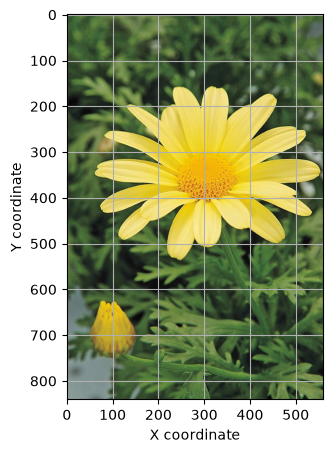

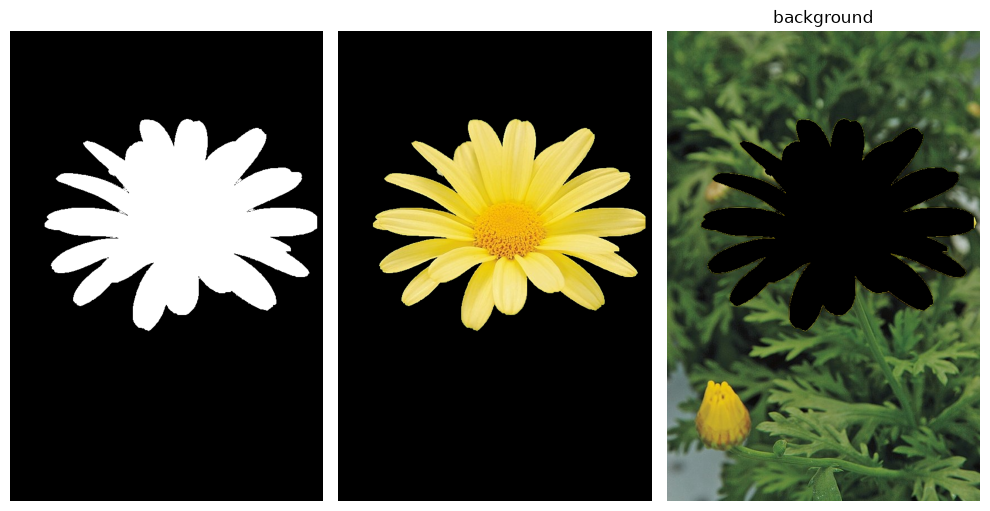

In [210]:
image9=cv.imread('C:\\Users\\USER\EN3160-Assignment-01\\images\\question9.jpeg')
mask=np.zeros(image9.shape[:2],np.uint8)

background_Model=np.zeros((1,65),np.float64)
foreground_model=np.zeros((1,65),np.float64)

# Now we built the rectangle, for that I manually choosing coordinates to get the rectangle
image_rgb = cv.cvtColor(image9, cv.COLOR_BGR2RGB)

# Display image with coordinates
plt.figure(figsize=(15, 5))
plt.imshow(image_rgb)
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid()
plt.show()

x = 50
y = 110

width = 550 - 50
height = 550 - 110

rect = (x, y, width, height)

cv.grabCut(
    image9,
    mask,
    rect,
    background_Model,
    foreground_model,
    5,
    cv.GC_INIT_WITH_RECT
)

final_mask = np.where(
    (mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD),
    255,
    0
).astype(np.uint8)

#foreground image
foreground_image = cv.bitwise_and(
    image9,
    image9,
    mask=final_mask
)

# backgroun image
background_mask = cv.bitwise_not(final_mask)

background_image = cv.bitwise_and(
    image9,
    image9,
    mask=background_mask
)
fig,axes =plt.subplots(1,3,figsize=(10,8))
axes[0].imshow(cv.cvtColor(final_mask,cv.COLOR_BGR2RGB))
axes[2].set_title('GrabCut Mask')
axes[1].imshow(cv.cvtColor(foreground_image,cv.COLOR_BGR2RGB))
axes[2].set_title('foreground')
axes[2].imshow(cv.cvtColor(background_image,cv.COLOR_BGR2RGB))
axes[2].set_title('background')
axes[0].axis('off')
axes[1].axis('off')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## (b)

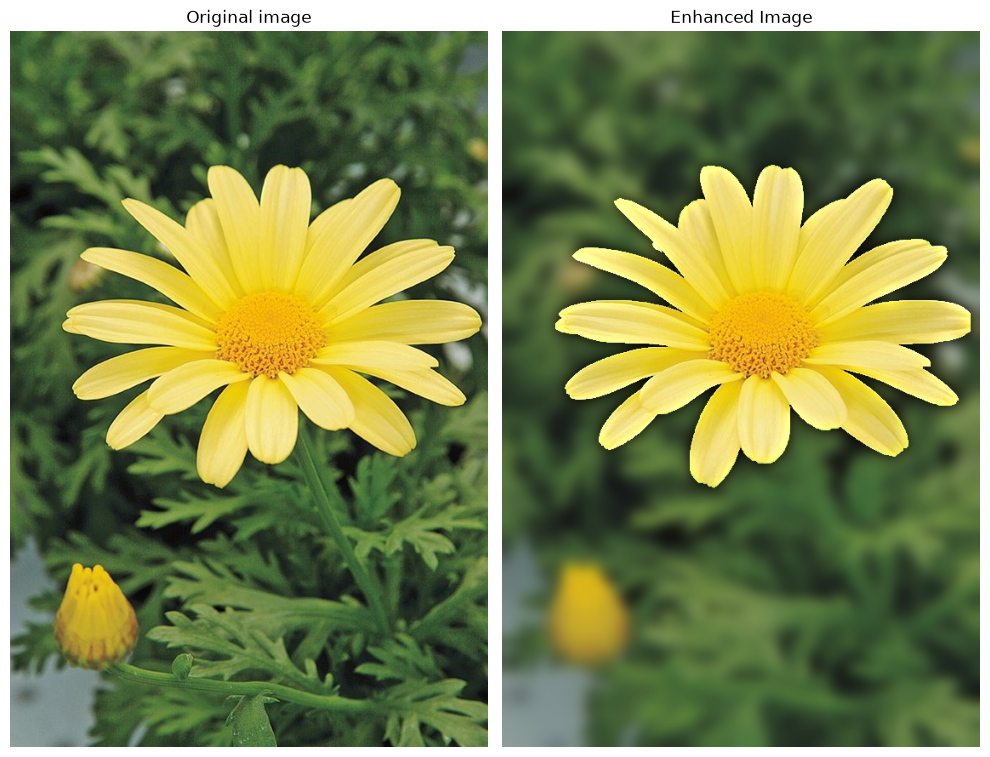

In [222]:
blurred_background=cv.GaussianBlur(background_image,(51,51),0)
enhanced_image = cv.add(foreground_image,blurred_background)

#original_image_rgb=cv.cvtColor(image9,cv.COLOR_BGR2RGB)
enhanced_image_rgb=cv.cvtColor(enhanced_image,cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(enhanced_image_rgb)
plt.title("Enhanced Image")
plt.axis('off')

plt.tight_layout()
plt.show()

## (c)
The dark region near the edge of the flower can occur because the segmentation mask contains background(black) pixels close to the flower boundary. When Gaussian blurring is applied, these dark pixels are averaged with neighboring background pixels. This causes the dark pixels to spread slightly into the surrounding background, producing a dark halo around the flower.

## Question 10


In this task, the image is smoothed using Gaussian and bilateral filters while aiming to preserve sharp edges. The results from OpenCV’s bilateral filter and my own implementation are then compared visually.


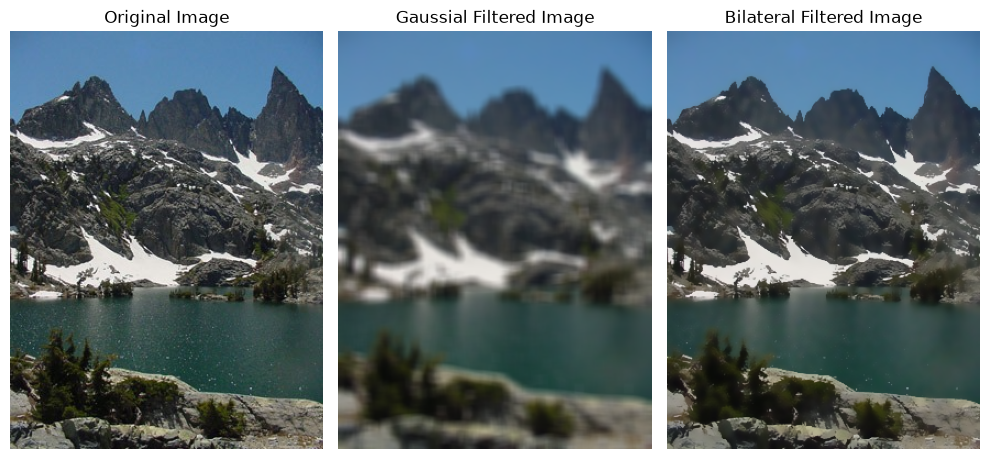

In [224]:
image10=cv.imread('C:\\Users\\USER\\EN3160-Assignment-01\\images\\question10.jpeg')
original_image=cv.cvtColor(image10, cv.COLOR_BGR2RGB)

gaussian_blurred=cv.GaussianBlur(image10,(9,9),75)
gb_image=cv.cvtColor(gaussian_blurred,cv.COLOR_BGR2RGB)

bilateral_im=cv.bilateralFilter(image10,9,sigmaColor=75,sigmaSpace=75)
bl_image=cv.cvtColor(bilateral_im,cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))

plt.subplot(1,3,1)
plt.imshow(original_image)
plt.axis('off')
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(gb_image)
plt.axis('off')
plt.title("Gaussial Filtered Image")

plt.subplot(1,3,3)
plt.imshow(bl_image)
plt.axis('off')
plt.title("Bilateral Filtered Image")

plt.tight_layout()
plt.show()

In this stage, a function is built to perform bilateral filtering. This function performs what directly perform by bilateral function in openCV


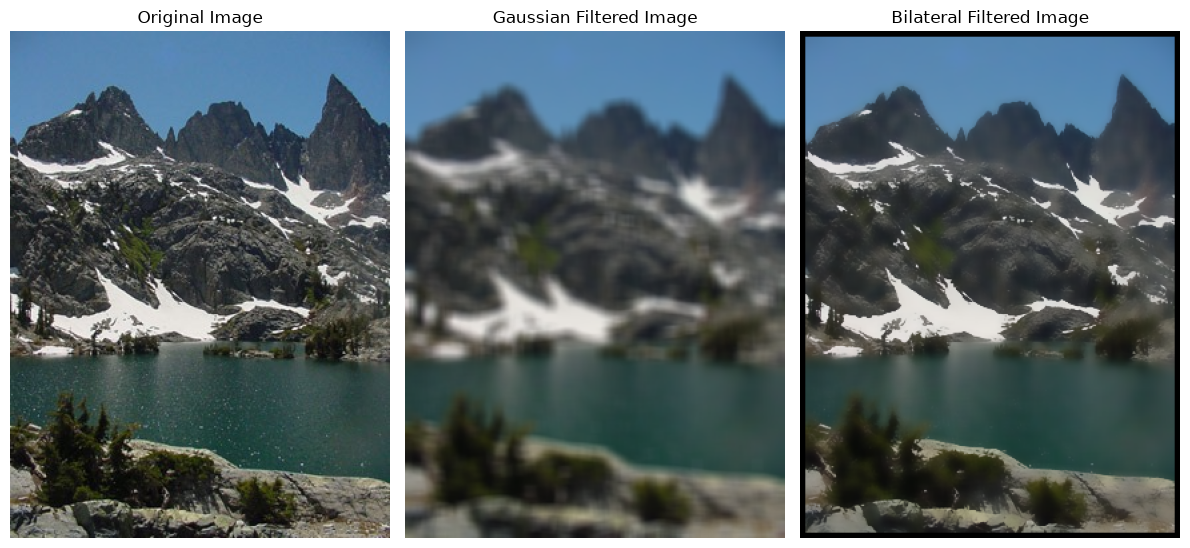

In [236]:
# Defining a manual function for the bilateral filter
def bilateral_filter(image, kernel_size, sigma_space, sigma_color):

    rows, columns, channels = image.shape
    radius = kernel_size // 2

    output_result = np.zeros_like(image)
    spatial_weights = np.zeros((kernel_size, kernel_size))

    for x in range(-radius, radius + 1):
        for y in range(-radius, radius + 1):
            distance_squared = x**2 + y**2
            spatial_weights[x + radius, y + radius] = np.exp(-distance_squared / (2 * sigma_space**2))

    # Go through every pixel
    for i in range(radius, rows - radius):
        for j in range(radius, columns - radius):
            # Center pixel
            center = image[i, j].astype(float)
            # Neighborhood
            neighborhood = image[i-radius:i+radius+1,j-radius:j+radius+1].astype(float)

            # Difference between every neighboring pixel and the center pixel
            difference = neighborhood - center

            # Calculate squared color difference
            color_difference_squared = np.sum(difference**2,axis=2)

            # Range weights
            range_weights = np.exp(-color_difference_squared /(2 * sigma_color**2))

            # Combine spatial and range weights
            weights = spatial_weights * range_weights

            # Weighted average for each color channel
            weighted_sum = np.sum(weights[:, :, np.newaxis] * neighborhood,axis=(0, 1))
            weight_sum = np.sum(weights)
            new_pixel_value = weighted_sum / weight_sum
            output_result[i, j] = new_pixel_value

    return output_result.astype(np.uint8)


# Now I Apply bilateral filter
bilateral_filtered_im = bilateral_filter(image10,9,sigma_space=75,sigma_color=75)

final_result1 = cv.cvtColor(bilateral_filtered_im,cv.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.axis('off')
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(gb_image)
plt.axis('off')
plt.title("Gaussian Filtered Image")

plt.subplot(1, 3, 3)
plt.imshow(final_result1)
plt.axis('off')
plt.title("Bilateral Filtered Image")

plt.tight_layout()
plt.show()

The bilateral filter reduced noise and smoothed the image while preserving important edges. 
Compared with the Gaussian filtered image, the bilateral filtered image maintains sharper edges because it considers both spatial distance and intensity differences when smoothing. 
This makes it more suitable for noise reduction while retaining image details.
